# Task 2: Hourly Pollutant Forecasting — Production Pipeline v3

**Model**: LightGBM ensemble with log1p target transform, Fourier features, anchor lags, target encoding, cross-station spatial features, and conformalized quantile regression (CQR) for calibrated 90% prediction intervals.

**Ensemble**: Optimized weighted average of LightGBM + Ridge (Fourier) + Seasonal Naive.

**Validation**: Walk-forward CV with 3 folds × 720h test windows.

In [1]:
import sys, os
sys.path.insert(0, '..')
os.makedirs("../outputs", exist_ok=True)

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data.loader import load_series
from src.forecasting.train import (
    train_forecast_pipeline, predict_with_pipeline,
    seasonal_naive_predict, walk_forward_cv
)
from src.forecasting.evaluate import evaluate_predictions, evaluate_intervals
from src.utils.constants import FORECAST_TARGETS

print(f"Targets: {len(FORECAST_TARGETS)}")
for t in FORECAST_TARGETS:
    print(f"  Station {t['station_code']}/{t['item_name']} → {t['start']} to {t['end']}")

Targets: 6
  Station 206/so2 → 2023-07-01 to 2023-07-31 23:00:00
  Station 211/no2 → 2023-08-01 to 2023-08-31 23:00:00
  Station 217/o3 → 2023-09-01 to 2023-09-30 23:00:00
  Station 219/co → 2023-10-01 to 2023-10-31 23:00:00
  Station 225/pm10 → 2023-11-01 to 2023-11-30 23:00:00
  Station 228/pm2.5 → 2023-12-01 to 2023-12-31 23:00:00


In [2]:
results = []
all_predictions = {}

for target in FORECAST_TARGETS:
    sc, ic, name = target["station_code"], target["item_code"], target["item_name"]
    pred_start, pred_end = target["start"], target["end"]

    print(f"\n{'='*70}")
    print(f"Station {sc} / {name} | Predict: {pred_start} to {pred_end}")
    print(f"{'='*70}")

    # Load and prepare
    raw = load_series(sc, ic, normal_only=True, end_before=pred_start)
    ts = raw["clean_value"].copy()
    full_idx = pd.date_range(ts.index.min(), ts.index.max(), freq="h")
    ts = ts.reindex(full_idx).ffill().bfill()
    overall_std = ts.std()

    print(f"Training: {len(ts)} hours | Std: {overall_std:.5f}")

    # --- Walk-forward CV ---
    folds = walk_forward_cv(ts, n_folds=3, test_size=720, min_train_size=8760)
    cv_metrics = {"naive": [], "lgbm": [], "ensemble": []}
    cv_intervals = []

    for fold in folds:
        ft = ts.iloc[:fold["train_end"]]
        fv = ts.iloc[fold["test_start"]:fold["test_end"]]

        pipe = train_forecast_pipeline(ft, fv, station_code=sc, item_code=ic)
        preds = predict_with_pipeline(pipe, fv.index)

        for mn, col in [("naive", "naive"), ("lgbm", "lgbm"), ("ensemble", "ensemble")]:
            m = evaluate_predictions(fv, preds[col])
            m["nrmse_overall"] = m["rmse"] / overall_std
            cv_metrics[mn].append(m)

        iv = evaluate_intervals(fv.values, preds["q05"].values, preds["q95"].values)
        cv_intervals.append(iv)

    for mn in cv_metrics:
        avg = {k: np.mean([m[k] for m in cv_metrics[mn]]) for k in cv_metrics[mn][0]}
        print(f"  {mn:>8}: RMSE={avg['rmse']:.5f}, nRMSE={avg['nrmse_overall']:.3f}, "
              f"R²={avg['r2']:.3f}, MAE={avg['mae']:.5f}")

    avg_iv = {k: np.mean([iv[k] for iv in cv_intervals]) for k in cv_intervals[0]}
    print(f"  Intervals: coverage={avg_iv['empirical_coverage']:.3f} (target 0.90), "
          f"width={avg_iv['avg_interval_width']:.5f}")

    # --- Final prediction ---
    val_start = ts.index.max() - pd.DateOffset(months=1) + pd.Timedelta(hours=1)
    train_final = ts.loc[:val_start - pd.Timedelta(hours=1)]
    val_final = ts.loc[val_start:]

    final_pipe = train_forecast_pipeline(train_final, val_final, station_code=sc, item_code=ic)
    full_pipe = train_forecast_pipeline(ts, station_code=sc, item_code=ic)
    full_pipe["weights"] = final_pipe["weights"]
    full_pipe["cqr_correction"] = final_pipe["cqr_correction"]

    pred_index = pd.date_range(pred_start, pred_end, freq="h")
    final_preds = predict_with_pipeline(full_pipe, pred_index)

    print(f"\n  Weights: { {k: round(v, 3) for k, v in full_pipe['weights'].items()} }")
    print(f"  CQR correction: {full_pipe['cqr_correction']:.5f}")
    print(f"  Predictions: {len(final_preds)} hours, "
          f"range=[{final_preds['ensemble'].min():.5f}, {final_preds['ensemble'].max():.5f}]")

    avg_ens = {k: np.mean([m[k] for m in cv_metrics["ensemble"]]) for k in cv_metrics["ensemble"][0]}
    avg_nav = {k: np.mean([m[k] for m in cv_metrics["naive"]]) for k in cv_metrics["naive"][0]}

    results.append({
        "station": sc, "pollutant": name,
        "cv_naive_rmse": round(avg_nav["rmse"], 5),
        "cv_ensemble_rmse": round(avg_ens["rmse"], 5),
        "cv_nrmse": round(avg_ens["nrmse_overall"], 3),
        "cv_r2": round(avg_ens["r2"], 3),
        "improvement_%": round((1 - avg_ens["rmse"] / avg_nav["rmse"]) * 100, 1),
        "interval_coverage": round(avg_iv["empirical_coverage"], 3),
    })

    all_predictions[f"{sc}_{name}"] = {
        "final": final_preds,
        "cv_last_fold_preds": preds,
        "cv_last_fold_actual": fv,
    }

print("\n\nAll targets processed.")


Station 206 / so2 | Predict: 2023-07-01 to 2023-07-31 23:00:00
Training: 21864 hours | Std: 0.00133


     naive: RMSE=0.00142, nRMSE=1.068, R²=-0.796, MAE=0.00114
      lgbm: RMSE=0.00113, nRMSE=0.852, R²=-0.063, MAE=0.00089
  ensemble: RMSE=0.00122, nRMSE=0.917, R²=-0.276, MAE=0.00099
  Intervals: coverage=0.938 (target 0.90), width=0.00299



  Weights: {'lgbm': np.float64(0.333), 'ridge': np.float64(0.333), 'naive': np.float64(0.333)}
  CQR correction: 0.00003
  Predictions: 744 hours, range=[0.00248, 0.00415]

Station 211 / no2 | Predict: 2023-08-01 to 2023-08-31 23:00:00
Training: 22608 hours | Std: 0.01574


     naive: RMSE=0.01364, nRMSE=0.866, R²=-1.369, MAE=0.01153
      lgbm: RMSE=0.01163, nRMSE=0.739, R²=-0.675, MAE=0.00975
  ensemble: RMSE=0.01131, nRMSE=0.719, R²=-0.528, MAE=0.00942
  Intervals: coverage=0.917 (target 0.90), width=0.03370



  Weights: {'lgbm': np.float64(0.333), 'ridge': np.float64(0.333), 'naive': np.float64(0.333)}
  CQR correction: 0.00218
  Predictions: 744 hours, range=[0.01299, 0.03088]

Station 217 / o3 | Predict: 2023-09-01 to 2023-09-30 23:00:00
Training: 23352 hours | Std: 0.01997


...


  Weights: {'lgbm': np.float64(0.375), 'ridge': np.float64(0.24), 'naive': np.float64(0.385)}
  CQR correction: -0.00125
  Predictions: 744 hours, range=[0.32880, 0.78318]

Station 225 / pm10 | Predict: 2023-11-01 to 2023-11-30 23:00:00
Training: 24816 hours | Std: 32.96530


     naive: RMSE=28.09975, nRMSE=0.852, R²=-2.622, MAE=23.43911
      lgbm: RMSE=19.78128, nRMSE=0.600, R²=-0.355, MAE=14.38148
  ensemble: RMSE=17.08213, nRMSE=0.518, R²=0.050, MAE=11.17452
  Intervals: coverage=0.931 (target 0.90), width=47.89999



  Weights: {'lgbm': np.float64(0.0), 'ridge': np.float64(1.0), 'naive': np.float64(0.0)}
  CQR correction: 2.94896
  Predictions: 720 hours, range=[28.19541, 50.79661]

Station 228 / pm2.5 | Predict: 2023-12-01 to 2023-12-31 23:00:00
Training: 25536 hours | Std: 18.68449


     naive: RMSE=14.03014, nRMSE=0.751, R²=-0.970, MAE=11.21808
      lgbm: RMSE=11.03748, nRMSE=0.591, R²=-0.183, MAE=8.60517
  ensemble: RMSE=10.21084, nRMSE=0.546, R²=0.005, MAE=7.64922
  Intervals: coverage=0.935 (target 0.90), width=37.90991



  Weights: {'lgbm': np.float64(1.0), 'ridge': np.float64(0.0), 'naive': np.float64(0.0)}
  CQR correction: 1.13306
  Predictions: 744 hours, range=[21.40116, 36.49245]


All targets processed.


In [3]:
results_df = pd.DataFrame(results)
print("Walk-Forward CV Results (3 folds × 720h):\n")
print(results_df.to_string(index=False))

Walk-Forward CV Results (3 folds × 720h):

 station pollutant  cv_naive_rmse  cv_ensemble_rmse  cv_nrmse  cv_r2  improvement_%  interval_coverage
     206       so2        0.00142           0.00122     0.917 -0.276           14.1              0.938
     211       no2        0.01364           0.01131     0.719 -0.528           17.0              0.917
     217        o3        0.01572           0.01428     0.715  0.363            9.2              0.905
     219        co        0.18147           0.13352     0.449  0.011           26.4              0.936
     225      pm10       28.09975          17.08213     0.518  0.050           39.2              0.931
     228     pm2.5       14.03014          10.21084     0.546  0.005           27.2              0.935


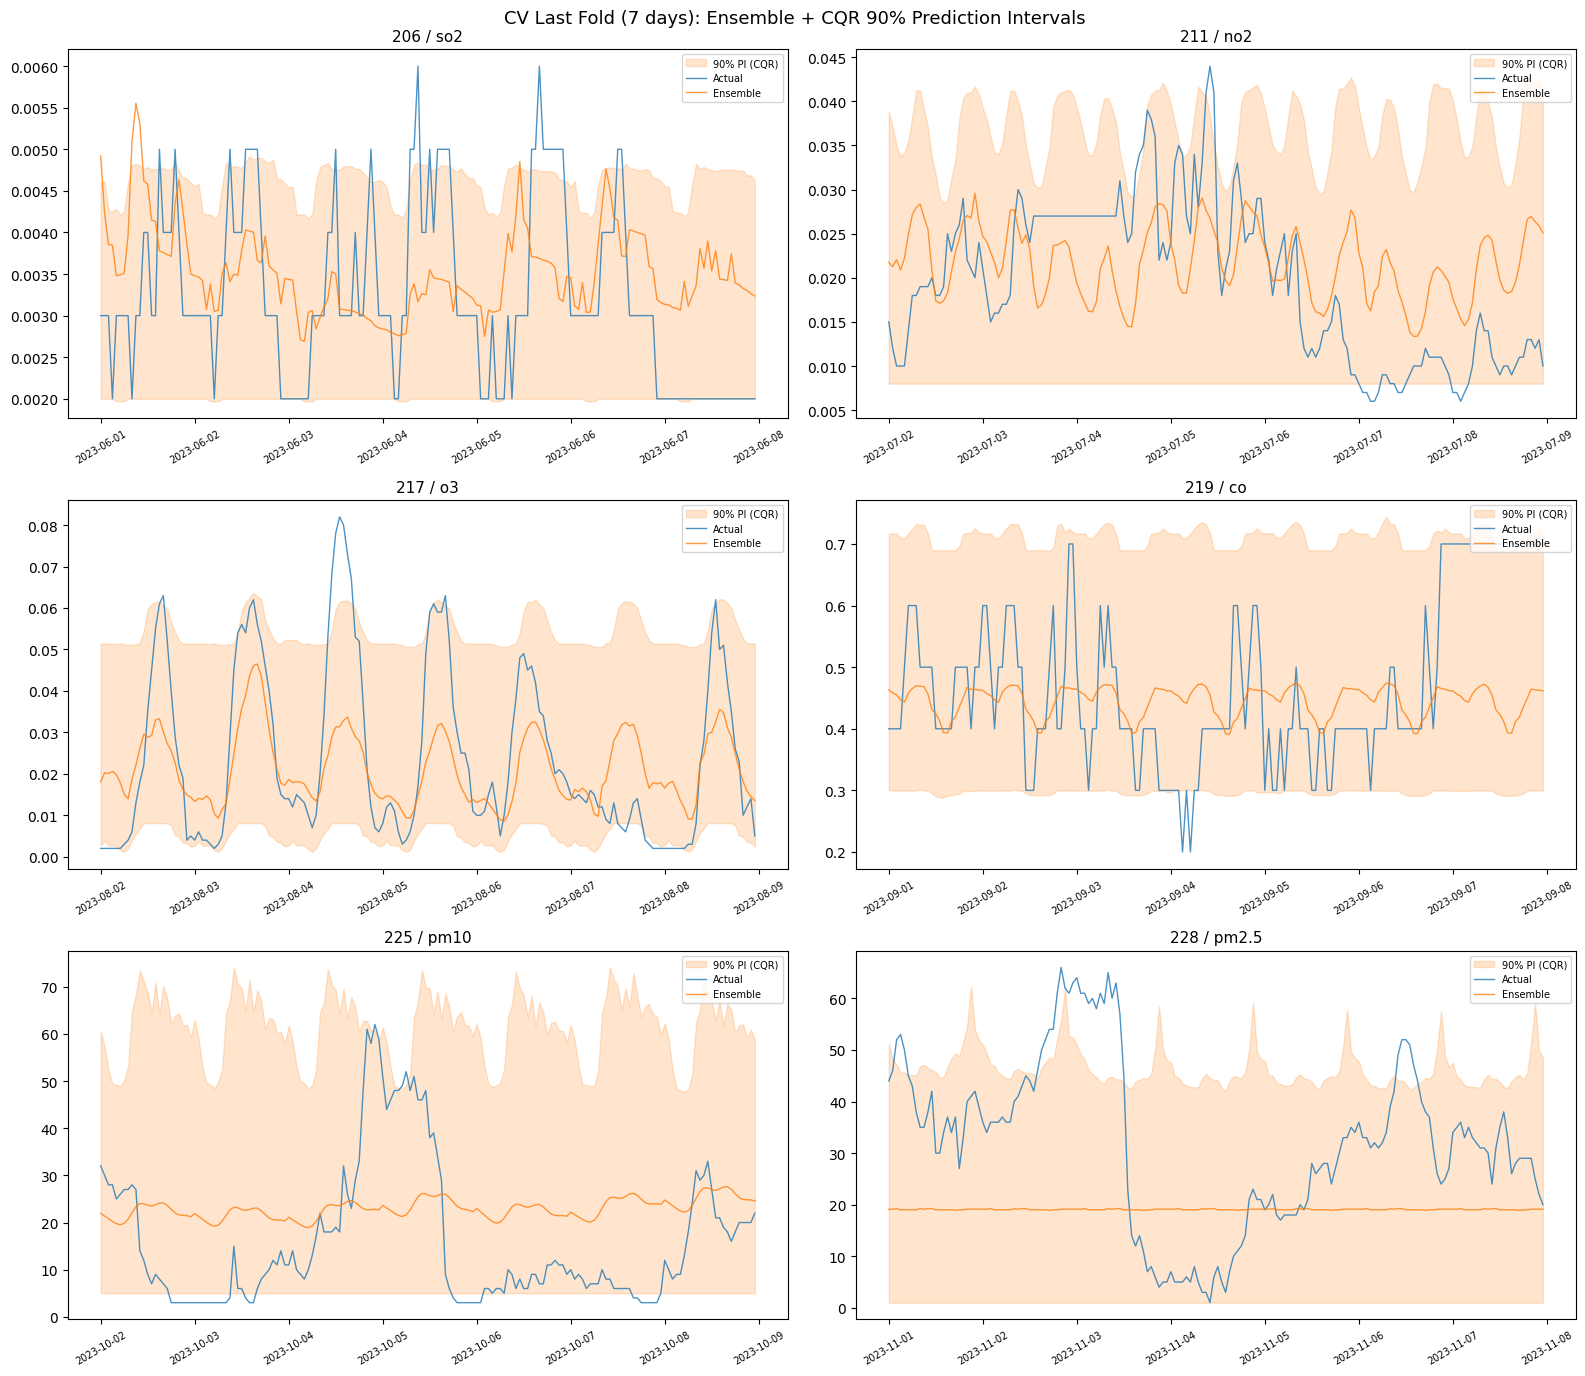

In [4]:
# Validation plot: last CV fold with calibrated intervals
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, (key, data) in enumerate(all_predictions.items()):
    ax = axes[i]
    actual = data["cv_last_fold_actual"]
    preds = data["cv_last_fold_preds"]
    n = min(168, len(actual))
    t = actual.index[:n]

    ax.fill_between(t, preds["q05"].iloc[:n], preds["q95"].iloc[:n],
                     alpha=0.2, color="C1", label="90% PI (CQR)")
    ax.plot(t, actual.iloc[:n], lw=1, alpha=0.8, label="Actual", color="C0")
    ax.plot(t, preds["ensemble"].iloc[:n], lw=1, alpha=0.8, label="Ensemble", color="C1")
    ax.set_title(key.replace("_", " / "), fontsize=11)
    ax.legend(fontsize=7, loc="upper right")
    ax.tick_params(axis='x', rotation=30, labelsize=7)

plt.suptitle("CV Last Fold (7 days): Ensemble + CQR 90% Prediction Intervals", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/forecast_validation_v3.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# Export final predictions with calibrated intervals
all_exports = []
for target in FORECAST_TARGETS:
    key = f"{target['station_code']}_{target['item_name']}"
    preds = all_predictions[key]["final"]
    df = pd.DataFrame({
        "measurement_datetime": preds.index,
        "station_code": target["station_code"],
        "item_code": target["item_code"],
        "item_name": target["item_name"],
        "predicted_value": preds["ensemble"].values,
        "predicted_lower_90": preds["q05"].values,
        "predicted_upper_90": preds["q95"].values,
    })
    all_exports.append(df)

export_df = pd.concat(all_exports, ignore_index=True)
export_df.to_csv("../outputs/forecast_predictions.csv", index=False)
print(f"Exported {len(export_df)} predictions with CQR-calibrated 90% intervals")
print(export_df.groupby(["station_code", "item_name"]).agg(
    count=("predicted_value", "count"),
    mean=("predicted_value", lambda x: round(x.mean(), 5)),
    min=("predicted_value", lambda x: round(x.min(), 5)),
    max=("predicted_value", lambda x: round(x.max(), 5)),
).to_string())

Exported 4416 predictions with CQR-calibrated 90% intervals
                        count      mean       min       max
station_code item_name                                     
206          so2          744   0.00333   0.00248   0.00415
211          no2          744   0.02361   0.01299   0.03088
217          o3           720   0.02567   0.00763   0.05240
219          co           744   0.51126   0.32880   0.78318
225          pm10         720  39.90390  28.19541  50.79661
228          pm2.5        744  26.37407  21.40116  36.49245
